In [1]:
# ============================================================
# K-1: MENYIAPKAN LINGKUNGAN
# ============================================================
import sys, time, os, json, sqlite3, gc, shutil
import pandas as pd
import numpy as np
import psutil

# Cek versi library
for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH  = "/content/lapisan_mentah"
DIR_KURASI  = "/content/lapisan_terkurasi"
DIR_SIMPAN  = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Fungsi pengukur (dari Praktikum 1) ---
proses  = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil   = fungsi()
    detik   = time.perf_counter() - t0
    catatan.append({
        "langkah"     : label,
        "detik"       : round(detik, 2),
        "delta_rss_mb": round(rss_mb() - m0, 1),
    })
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Lineage (baru di Praktikum 3) ---
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber"    : nama,
        "asal"      : asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris,
        "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")



pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ============================================================
# K-2: AKUISISI 1 — UNDUHAN BERKALA YANG TAHAN GAGAL
# ============================================================
import requests

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            t_mulai = time.perf_counter()
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                ukuran = 0
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
                        ukuran += len(chunk)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            detik  = time.perf_counter() - t_mulai
            kbps   = (ukuran / 1024**2) / detik
            os.replace(sementara, tujuan)          # atomik
            print(f"✅ Selesai: {os.path.basename(tujuan)} ({ukuran/1024**2:.2f} MB, {kbps:.2f} MB/s)")
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_ZONA = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
    "trip_distance", "PULocationID", "DOLocationID", "payment_type",
    "fare_amount", "tip_amount", "total_amount",
]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA, compression="gzip")

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")

print(f"\nBentuk data trip : {trip.shape}")
print(f"Bentuk data zona : {zona.shape}")
zona.head()

cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s
cache ditemukan: taxi_zone_lookup.csv
[unduh zona] 0.00 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.0 MB
[baca trip] 3.90 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris

Bentuk data trip : (3066766, 10)
Bentuk data zona : (265, 4)


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [3]:
# ============================================================
# K-3: AKUISISI 2 — MEMANGGIL API JSON (Open-Meteo)
# ============================================================
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude" : lat,
        "longitude": lon,
        "start_date": mulai,
        "end_date"  : selesai,
        "hourly"    : "temperature_2m,precipitation",
        "timezone"  : "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):
            time.sleep(2 ** i)
            continue
        r.raise_for_status()
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={
    "time"           : "jam_mulai",
    "temperature_2m" : "suhu_c",
    "precipitation"  : "hujan_mm",
})

catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")

# Verifikasi: Januari 2023 = 31 hari × 24 jam = 744 baris
jam_diharapkan = 31 * 24
print(f"\nBaris cuaca    : {len(cuaca):,}")
print(f"Jam diharapkan : {jam_diharapkan}")
print(f"Selisih        : {len(cuaca) - jam_diharapkan} jam {'⚠️ ada jam hilang!' if len(cuaca) != jam_diharapkan else '✅'}")
cuaca.head()

[ambil cuaca] 0.46 s
[lineage] cuaca: 744 baris

Baris cuaca    : 744
Jam diharapkan : 744
Selisih        : 0 jam ✅


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


In [4]:
# ============================================================
# K-4: JALUR CADANGAN — DATA SINTETIS
# ============================================================
# Jalankan HANYA jika K-3 gagal total

def cuaca_sintetis(mulai="2023-01-01", selesai="2023-01-31", seed=7):
    jam = pd.date_range(mulai, pd.Timestamp(selesai) + pd.Timedelta("23h"), freq="h")
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        "jam_mulai": jam,
        "suhu_c"   : np.round(rng.normal(3, 5, len(jam)), 1),
        "hujan_mm" : np.round(rng.gamma(0.4, 0.8, len(jam)), 2),
    })

# Aktifkan baris di bawah jika diperlukan:
# cuaca = cuaca_sintetis()
# catat_sumber("cuaca", "sintetis", len(cuaca), "PENGGANTI - bukan data nyata")
print("K-4 siap (tidak aktif — K-3 berhasil).")

K-4 siap (tidak aktif — K-3 berhasil).


In [5]:
# ============================================================
# K-4: JALUR CADANGAN — DATA SINTETIS
# ============================================================
# Jalankan HANYA jika K-3 gagal total

def cuaca_sintetis(mulai="2023-01-01", selesai="2023-01-31", seed=7):
    jam = pd.date_range(mulai, pd.Timestamp(selesai) + pd.Timedelta("23h"), freq="h")
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        "jam_mulai": jam,
        "suhu_c"   : np.round(rng.normal(3, 5, len(jam)), 1),
        "hujan_mm" : np.round(rng.gamma(0.4, 0.8, len(jam)), 2),
    })

# Aktifkan baris di bawah jika diperlukan:
# cuaca = cuaca_sintetis()
# catat_sumber("cuaca", "sintetis", len(cuaca), "PENGGANTI - bukan data nyata")
print("K-4 siap (tidak aktif — K-3 berhasil).")

K-4 siap (tidak aktif — K-3 berhasil).


In [6]:
# ============================================================
# K-5: AKUISISI 3 — BASIS DATA SQLite (Pemuatan Bertahap)
# ============================================================
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine  = create_engine(f"sqlite:///{PATH_DB}")

# Buat tabel referensi tarif
tarif_referensi = pd.DataFrame({
    "payment_type"   : [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                         "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# Simpan subset trip ke SQLite (simulasi sistem operasional)
trip.head(300_000).to_sql(
    "trip_operasional", engine,
    if_exists="replace", index=False, chunksize=50_000,
)
print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine
)["name"].tolist())

# Kueri agregasi
SQL = """
    SELECT payment_type,
           COUNT(*)          AS jumlah,
           AVG(total_amount) AS rata_total
    FROM   trip_operasional
    WHERE  total_amount > 0
    GROUP  BY payment_type
    ORDER  BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                           engine, chunksize=50_000):
    total_baris += len(bagian)
print(f"\nDibaca bertahap: {total_baris:,} baris")

# Muat ulang tarif_referensi dari DB (simulasi membaca sistem operasional)
tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691

Dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


In [7]:
# ============================================================
# K-6: PROFILING KUALITAS DATA PADA ENAM DIMENSI
# ============================================================

# Tambah kolom durasi sebelum profiling
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom"        : kol,
            "tipe"         : str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik"   : s.nunique(dropna=True),
            "contoh"       : s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
print("=== PROFIL KOLOM ===")
print(profil.to_string(index=False))

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah    = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada"   : trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat"     : ~trip.duplicated(),
    "validitas: jarak 0-100 mil"         : trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0"        : trip["total_amount"] > 0,
    "validitas: PULocationID dikenal"    : trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit"    : trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare"         : trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023"    : trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {
        "aturan"      : nama,
        "lulus"       : int(mask.sum()),
        "gagal"       : int((~mask).sum()),
        "persen_gagal": round(100 * (~mask).mean(), 3),
    }
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False).reset_index(drop=True)

print("\n=== LAPORAN KUALITAS DATA ===")
print(laporan.to_string(index=False))

=== PROFIL KOLOM ===
                kolom           tipe  persen_hilang  nilai_unik              contoh
 tpep_pickup_datetime datetime64[us]          0.000     1610975 2023-01-01 00:32:10
tpep_dropoff_datetime datetime64[us]          0.000     1611319 2023-01-01 00:40:36
      passenger_count        float64          2.339          10                 1.0
        trip_distance        float64          0.000        4387                0.97
         PULocationID          int64          0.000         257                 161
         DOLocationID          int64          0.000         261                 141
         payment_type          int64          0.000           5                   2
          fare_amount        float64          0.000        6873                 9.3
           tip_amount        float64          0.000        4036                 0.0
         total_amount        float64          0.000       15871                14.3
         durasi_menit        float64          0.000    

In [8]:
# ============================================================
# K-7: NILAI HILANG DAN DUPLIKAT
# ============================================================
KOL = "passenger_count"
asli = trip[KOL]
print(f"Persen hilang '{KOL}': {round(100 * asli.isna().mean(), 3)}%")

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

strategi = {
    "1_dibuang"       : asli.dropna(),
    "2_isi_median"    : asli.fillna(asli.median()),
    "3_isi_modus"     : asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam" : asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {
        "strategi": nama,
        "n"       : len(s),
        "mean"    : round(s.mean(), 4),
        "median"  : s.median(),
        "std"     : round(s.std(), 4),
    }
    for nama, s in strategi.items()
])
print("\n=== PERBANDINGAN STRATEGI NILAI HILANG ===")
print(banding.to_string(index=False))

# Strategi terpilih: tandai + isi per kelompok
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())   # jaring pengaman

# Duplikat
dup_penuh = trip.duplicated().sum()
KUNCI = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID", "total_amount",
]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"\nDuplikat penuh    : {dup_penuh:,}")
print(f"Duplikat pd kunci : {dup_kunci:,}")

sebelum = len(trip)
trip    = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris (hapus {sebelum - len(trip):,} duplikat)")

Persen hilang 'passenger_count': 2.339%

=== PERBANDINGAN STRATEGI NILAI HILANG ===
       strategi       n   mean  median    std
      1_dibuang 2995023 1.3625     1.0 0.8961
   2_isi_median 3066766 1.3541     1.0 0.8873
    3_isi_modus 3066766 1.3541     1.0 0.8873
4_median_perjam 3066766 1.3541     1.0 0.8873

Duplikat penuh    : 0
Duplikat pd kunci : 1
3,066,766 -> 3,066,765 baris (hapus 1 duplikat)


In [9]:
# ============================================================
# K-8: OUTLIER, JOIN TABEL REFERENSI, GABUNG BERBASIS WAKTU
# ============================================================

def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr    = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s      = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z      = (s - s.mean()) / s.std()
        hasil.append({
            "kolom"      : kol,
            "batas_bawah": round(lo, 2),
            "batas_atas" : round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3" : int((z.abs() > 3).sum()),
            "p99"        : round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

print("=== RINGKASAN OUTLIER ===")
print(ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"]).to_string(index=False))

# Filter baris layak
layak  = (
    trip["trip_distance"].between(0.01, 100)
    & trip["durasi_menit"].between(1, 180)
    & (trip["total_amount"] > 0)
)
bersih = trip.loc[layak].copy()

# Tandai outlier tarif (jangan dibuang)
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# Winsorizing jarak (untuk fitur model)
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"\n{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# --- JOIN 1: tabel zona (dimensi) ---
print("\nKunci zona unik?", zona["LocationID"].is_unique)
n0     = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]].rename(
        columns={"Borough": "borough_naik", "Zone": "zona_naik"}
    ),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one",
)
bersih = bersih.drop(columns="LocationID")
print(f"Setelah join zona  : {n0:,} -> {len(bersih):,} baris")
print(f"Zona tak dikenal   : {bersih['zona_naik'].isna().sum():,}")

# --- JOIN 2: tabel pembayaran (dari SQLite) ---
bersih = bersih.merge(
    tarif_referensi[["payment_type", "nama_pembayaran"]],
    on="payment_type", how="left", validate="many_to_one",
)

# --- JOIN 3: cuaca berbasis jam ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0     = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"Setelah join cuaca : {n0:,} -> {len(bersih):,} baris")
print(f"Tanpa data cuaca   : {bersih['suhu_c'].isna().sum():,}")

=== RINGKASAN OUTLIER ===
        kolom  batas_bawah  batas_atas  outlier_iqr  outlier_z3    p99
trip_distance        -2.35        6.74       390244          67  20.06
 durasi_menit        -9.66       35.08       170615        3175  57.25
 total_amount        -4.55       48.65       371616       87248 101.94

3,066,765 -> 2,986,910 baris (2.60% dibuang)

Kunci zona unik? True
Setelah join zona  : 2,986,910 -> 2,986,910 baris
Zona tak dikenal   : 37,609
Setelah join cuaca : 2,986,910 -> 2,986,910 baris
Tanpa data cuaca   : 37


In [10]:
# ============================================================
# K-9: REKAYASA FITUR — ENCODING DAN SCALING TANPA KEBOCORAN
# ============================================================
bersih["hari_minggu"]   = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"]   = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"]  / bersih["trip_distance"]).round(3)
bersih["hujan"]         = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42
)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

# Scaling — fit HANYA pada data latih
skala    = StandardScaler().fit(latih[FITUR_NUM])
latih_num = skala.transform(latih[FITUR_NUM])
uji_num   = skala.transform(uji[FITUR_NUM])

print("Mean data latih (harus ~0) :", latih_num.mean(axis=0).round(3))
print("Mean data uji   (≠ 0)      :", uji_num.mean(axis=0).round(3))

# One-Hot Encoding
enc     = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print(f"\nJumlah kolom hasil one-hot : {latih_kat.shape[1]}")
print("Nama kolom (6 pertama)     :", enc.get_feature_names_out()[:6].tolist(), "...")

Mean data latih (harus ~0) : [-0.  0. -0.]
Mean data uji   (≠ 0)      : [ 0.001  0.001 -0.009]

Jumlah kolom hasil one-hot : 11
Nama kolom (6 pertama)     : ['nama_pembayaran_Gratis', 'nama_pembayaran_Kartu kredit', 'nama_pembayaran_Sengketa', 'nama_pembayaran_Tunai', 'borough_naik_Bronx', 'borough_naik_Brooklyn'] ...


In [11]:
# ============================================================
# K-10: PIPELINE LENGKAP, VALIDASI SKEMA, SIMPAN BERPARTISI
# ============================================================
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]",
    "trip_distance"       : "float64",
    "durasi_menit"        : "float64",
    "total_amount"        : "float64",
    "borough_naik"        : "object",
    "nama_pembayaran"     : "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"✅ Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z  = pd.read_csv(path_zona, compression="gzip")   # ← fix gzip
    df["durasi_menit"] = (
        (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
        .dt.total_seconds() / 60
    )
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median")
    )
    df = df.drop_duplicates(subset=KUNCI)
    df = df[
        df["trip_distance"].between(0.01, 100)
        & df["durasi_menit"].between(1, 180)
        & (df["total_amount"] > 0)
    ]
    df = (
        df.merge(
            z[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
            left_on="PULocationID", right_on="LocationID",
            how="left", validate="many_to_one",
        )
        .drop(columns="LocationID")
        .merge(
            df_tarif[["payment_type", "nama_pembayaran"]],
            on="payment_type", how="left", validate="many_to_one",
        )
    )
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    return validasi(df)

# Jalankan pipeline
hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

# Simpan berpartisi
OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False
))
print("Partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("Idempoten?", len(ulang) == len(hasil))

# Simpan artefak ke Drive
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)
print("\n✅ Semua artefak tersimpan di Drive.")

✅ Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 9.07 s
[tulis parquet berpartisi] 8.95 s
Partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
✅ Validasi lulus: 2,986,910 baris x 17 kolom
Idempoten? True

✅ Semua artefak tersimpan di Drive.


In [12]:
# ============================================================
# K-11: PRA-PEMROSESAN SETARA PYSPARK (TAMBAHAN) — REVISI
# ============================================================
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-P03")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.session.timeZone", "America/New_York")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

sdf   = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (
    sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates([
        "tpep_pickup_datetime", "tpep_dropoff_datetime",
        "PULocationID", "DOLocationID", "total_amount",
    ])
    .join(F.broadcast(szona),
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID")
)

n_spark = ukur("spark: hitung baris bersih", lambda: sbersih.count())
print(f"\nBaris bersih (Spark)  : {n_spark:,}")
print(f"Baris bersih (pandas) : {len(hasil):,}")
print(f"Selisih               : {abs(n_spark - len(hasil)):,}")

sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)
sbersih.write.mode("overwrite").partitionBy("Borough").parquet(
    "/content/lapisan_terkurasi/trips_spark"
)
sbersih.explain()

spark.stop()
print("✅ K-11 selesai.")

[spark: hitung baris bersih] 18.70 s

Baris bersih (Spark)  : 2,986,910
Baris bersih (pandas) : 2,986,910
Selisih               : 0
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocationID#8L, payment_type#249L, fare_amount#251, tip_amount#253, total_amount#16, durasi_menit#255, Borough#50]
   +- BroadcastHashJoin [PULocationID#7L], [LocationID#49L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#8L, tpep_dropoff_datetime#2, PULocationID#7L, total_amount#16, tpep_pickup_datetime#1], functions=[first(passenger_count#3, false), first(trip_distance#4, fa

LATIHAN

In [13]:
# LATIHAN 1: unduh_aman dengan cetak kecepatan + bukti cache
def unduh_aman_v2(url, tujuan, percobaan=3, jeda_awal=2):
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print(f"[CACHE HIT] {os.path.basename(tujuan)} — tidak perlu mengunduh ulang.")
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            t_mulai = time.perf_counter()
            ukuran  = 0
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
                        ukuran += len(chunk)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            detik   = time.perf_counter() - t_mulai
            mbps    = (ukuran / 1024**2) / detik
            os.replace(sementara, tujuan)
            print(f"[UNDUH] {os.path.basename(tujuan)}: {ukuran/1024**2:.2f} MB "
                  f"dalam {detik:.2f}s = {mbps:.2f} MB/s")
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan")

# Panggilan 1 — akan mengunduh (karena file sudah ada, harusnya cache)
print("=== Panggilan ke-1 ===")
unduh_aman_v2(URL_ZONA, PATH_ZONA)

print("\n=== Panggilan ke-2 (harus pakai cache) ===")
unduh_aman_v2(URL_ZONA, PATH_ZONA)

=== Panggilan ke-1 ===
[CACHE HIT] taxi_zone_lookup.csv — tidak perlu mengunduh ulang.

=== Panggilan ke-2 (harus pakai cache) ===
[CACHE HIT] taxi_zone_lookup.csv — tidak perlu mengunduh ulang.


'/content/lapisan_mentah/taxi_zone_lookup.csv'

In [14]:
# LATIHAN 2: Tambah 2 aturan baru ke laporan kualitas
aturan_tambahan = {
    "validitas: tip_amount >= 0"         : trip["tip_amount"] >= 0,
    "konsistensi: tip <= total_amount"   : trip["tip_amount"] <= trip["total_amount"],
}

laporan_tambahan = pd.DataFrame([
    {
        "aturan"      : nama,
        "lulus"       : int(mask.sum()),
        "gagal"       : int((~mask).sum()),
        "persen_gagal": round(100 * (~mask).mean(), 3),
    }
    for nama, mask in aturan_tambahan.items()
])

laporan_lengkap = pd.concat([laporan, laporan_tambahan], ignore_index=True) \
                    .sort_values("persen_gagal", ascending=False)
print(laporan_lengkap.to_string(index=False))

                          aturan   lulus  gagal  persen_gagal
kelengkapan: passenger_count ada 2995023  71743         2.339
      validitas: jarak 0-100 mil 3020816  45950         1.498
 konsistensi: durasi 1-180 menit 3030383  36383         1.186
     validitas: total_amount > 0 3040994  25772         0.840
konsistensi: tip <= total_amount 3041561  25204         0.822
      konsistensi: total >= fare 3041743  25023         0.816
      validitas: tip_amount >= 0 3066540    225         0.007
 ketepatan waktu: dalam Jan 2023 3066718     48         0.002
 validitas: PULocationID dikenal 3066766      0         0.000
  keunikan: baris tidak duplikat 3066766      0         0.000


In [15]:
# LATIHAN 3: Join DOLocationID, hitung 10 pasangan borough asal-tujuan tersibuk
bersih_do = bersih.merge(
    zona[["LocationID", "Borough"]].rename(
        columns={"Borough": "borough_turun"}
    ),
    left_on="DOLocationID", right_on="LocationID",
    how="left", validate="many_to_one",
).drop(columns="LocationID")

top10_pasangan = (
    bersih_do
    .groupby(["borough_naik", "borough_turun"], observed=True)
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values("jumlah_perjalanan", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("=== 10 PASANGAN BOROUGH TERSIBUK ===")
print(top10_pasangan.to_string(index=False))

=== 10 PASANGAN BOROUGH TERSIBUK ===
borough_naik borough_turun  jumlah_perjalanan
   Manhattan     Manhattan            2491566
      Queens     Manhattan             155261
   Manhattan        Queens              82354
   Manhattan      Brooklyn              62986
      Queens        Queens              59146
      Queens      Brooklyn              42187
     Unknown     Manhattan              18432
     Unknown       Unknown              13562
   Manhattan         Bronx               8865
    Brooklyn      Brooklyn               7910


In [16]:
# LATIHAN 4: MinMaxScaler vs StandardScaler
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler().fit(latih[FITUR_NUM])
latih_mm = minmax.transform(latih[FITUR_NUM])
uji_mm   = minmax.transform(uji[FITUR_NUM])

print("=== StandardScaler (latih) ===")
print(f"  Min : {latih_num.min(axis=0).round(3)}")
print(f"  Max : {latih_num.max(axis=0).round(3)}")
print(f"  Std : {latih_num.std(axis=0).round(3)}")

print("\n=== MinMaxScaler (latih) ===")
print(f"  Min : {latih_mm.min(axis=0).round(3)}")
print(f"  Max : {latih_mm.max(axis=0).round(3)}")
print(f"  Std : {latih_mm.std(axis=0).round(3)}")

print("""
KESIMPULAN:
- StandardScaler → distribusi ~N(0,1). Cocok untuk: Regresi Logistik, SVM, PCA, Neural Network.
- MinMaxScaler   → rentang [0,1].       Cocok untuk: KNN, Neural Network dengan aktivasi sigmoid.
- Tidak penting  → Decision Tree, Random Forest, XGBoost (berbasis pohon, tidak sensitif skala).
- MinMaxScaler lebih sensitif terhadap outlier karena batas min/max dipengaruhi nilai ekstrem.
""")

=== StandardScaler (latih) ===
  Min : [-0.794 -1.226 -2.288]
  Max : [ 4.247 13.925  3.347]
  Std : [1. 1. 1.]

=== MinMaxScaler (latih) ===
  Min : [0. 0. 0.]
  Max : [1. 1. 1.]
  Std : [0.198 0.066 0.177]

KESIMPULAN:
- StandardScaler → distribusi ~N(0,1). Cocok untuk: Regresi Logistik, SVM, PCA, Neural Network.
- MinMaxScaler   → rentang [0,1].       Cocok untuk: KNN, Neural Network dengan aktivasi sigmoid.
- Tidak penting  → Decision Tree, Random Forest, XGBoost (berbasis pohon, tidak sensitif skala).
- MinMaxScaler lebih sensitif terhadap outlier karena batas min/max dipengaruhi nilai ekstrem.



In [17]:
# LATIHAN 5: Sengaja duplikasi baris zona, buktikan error muncul
zona_duplikat = pd.concat([zona, zona.iloc[[0]]], ignore_index=True)
print(f"Zona original : {len(zona)} baris | Zona duplikat : {len(zona_duplikat)} baris")
print(f"LocationID unik? {zona_duplikat['LocationID'].is_unique}")

try:
    _ = bersih.merge(
        zona_duplikat[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
        left_on="PULocationID", right_on="LocationID",
        how="left", validate="many_to_one",    # harus error
    )
    print("❌ Tidak ada error — tidak diharapkan!")
except Exception as e:
    print(f"✅ Error tertangkap (diharapkan): {type(e).__name__}: {e}")

# Kembalikan ke tabel zona semula
print("\n✅ Tabel zona asli tetap utuh, tidak dimodifikasi.")

Zona original : 265 baris | Zona duplikat : 266 baris
LocationID unik? False
✅ Error tertangkap (diharapkan): MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

✅ Tabel zona asli tetap utuh, tidak dimodifikasi.


In [18]:
# LATIHAN 6: Pipeline inkremental (hanya proses bulan yang belum ada)
import glob

OUT_INKR = os.path.join(DIR_KURASI, "trips_inkremental")
os.makedirs(OUT_INKR, exist_ok=True)

# Pemetaan bulan → URL TLC
def url_tlc(tahun, bulan):
    return (f"https://d37ci6vzurychx.cloudfront.net/trip-data/"
            f"yellow_tripdata_{tahun}-{bulan:02d}.parquet")

def pipeline_inkremental(tahun, bulan):
    tag      = f"{tahun}-{bulan:02d}"
    out_dir  = os.path.join(OUT_INKR, f"bulan={tag}")

    # Cek apakah sudah diproses
    if os.path.isdir(out_dir) and len(os.listdir(out_dir)) > 0:
        print(f"[SKIP] Bulan {tag} sudah ada di {out_dir}")
        return

    print(f"[PROSES] Memproses bulan {tag}...")
    path_lokal = os.path.join(DIR_MENTAH, f"yellow_tripdata_{tag}.parquet")
    unduh_aman(url_tlc(tahun, bulan), path_lokal)

    df = pipeline(path_lokal, PATH_ZONA, cuaca, tarif_referensi)
    df.to_parquet(out_dir, index=False)
    print(f"[SELESAI] {len(df):,} baris -> {out_dir}")

# Jalankan 2x untuk buktikan idempotensi
print("=== Jalankan ke-1 ===")
pipeline_inkremental(2023, 1)

print("\n=== Jalankan ke-2 (harus SKIP) ===")
pipeline_inkremental(2023, 1)

print("\nDirektori output:", os.listdir(OUT_INKR))

=== Jalankan ke-1 ===
[PROSES] Memproses bulan 2023-01...
cache ditemukan: yellow_tripdata_2023-01.parquet
✅ Validasi lulus: 2,986,910 baris x 17 kolom
[SELESAI] 2,986,910 baris -> /content/lapisan_terkurasi/trips_inkremental/bulan=2023-01

=== Jalankan ke-2 (harus SKIP) ===
[PROSES] Memproses bulan 2023-01...
cache ditemukan: yellow_tripdata_2023-01.parquet
✅ Validasi lulus: 2,986,910 baris x 17 kolom
[SELESAI] 2,986,910 baris -> /content/lapisan_terkurasi/trips_inkremental/bulan=2023-01

Direktori output: ['bulan=2023-01']


Tugas Praktikum

In [19]:
# TUGAS 1: Pipeline dua bulan (Januari & Juli 2023)
BULAN_TUGAS = [(2023, 1), (2023, 7)]
OUT_TUGAS   = os.path.join(DIR_KURASI, "trips_dua_bulan")
os.makedirs(OUT_TUGAS, exist_ok=True)

baris_per_bulan = {}
for tahun, bulan in BULAN_TUGAS:
    tag        = f"{tahun}-{bulan:02d}"
    path_lokal = os.path.join(DIR_MENTAH, f"yellow_tripdata_{tag}.parquet")

    # Unduh jika belum ada
    unduh_aman(url_tlc(tahun, bulan), path_lokal)

    # Ambil cuaca bulan yang sesuai
    if bulan == 1:
        df_cuaca_bulan = cuaca  # Jan sudah ada
    else:
        # Juli 2023
        df_cuaca_bulan = ukur(f"ambil cuaca {tag}",
                               lambda: ambil_cuaca(f"{tahun}-{bulan:02d}-01",
                                                   f"{tahun}-{bulan:02d}-31"))
        df_cuaca_bulan["time"] = pd.to_datetime(df_cuaca_bulan.get("time",
                                                df_cuaca_bulan.get("jam_mulai")))
        df_cuaca_bulan = df_cuaca_bulan.rename(columns={
            "time": "jam_mulai", "temperature_2m": "suhu_c", "precipitation": "hujan_mm"
        }) if "temperature_2m" in df_cuaca_bulan.columns else df_cuaca_bulan

    df_bulan = ukur(f"pipeline {tag}", lambda p=path_lokal, c=df_cuaca_bulan:
                    pipeline(p, PATH_ZONA, c, tarif_referensi))

    # Simpan berpartisi per bulan
    df_bulan["bulan"] = tag
    out_b = os.path.join(OUT_TUGAS, f"bulan={tag}")
    df_bulan.to_parquet(out_b, index=False)
    baris_per_bulan[tag] = len(df_bulan)
    print(f"Bulan {tag}: {len(df_bulan):,} baris tersimpan")

print("\n=== RINGKASAN DUA BULAN ===")
for bulan, n in baris_per_bulan.items():
    print(f"  {bulan}: {n:,} baris")

# Bukti tidak ada duplikasi antar-bulan
import glob

# Cari semua file parquet di dalam OUT_TUGAS secara rekursif
file_parquet = glob.glob(os.path.join(OUT_TUGAS, "**", "*.parquet"), recursive=True)
print(f"File parquet ditemukan: {len(file_parquet)}")
print(os.listdir(OUT_TUGAS))

semua = pd.concat([
    pd.read_parquet(os.path.join(OUT_TUGAS, f"bulan={t}-{b:02d}"))
    for t, b in BULAN_TUGAS
], ignore_index=True)

dup_antar = semua.duplicated(subset=KUNCI).sum()
print(f"Total baris gabungan  : {len(semua):,}")
print(f"Duplikat antar-bulan  : {dup_antar} ({'✅ aman' if dup_antar == 0 else '❌ ada duplikat'})")

cache ditemukan: yellow_tripdata_2023-01.parquet
✅ Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline 2023-01] 8.27 s
Bulan 2023-01: 2,986,910 baris tersimpan
cache ditemukan: yellow_tripdata_2023-07.parquet
[ambil cuaca 2023-07] 0.39 s
✅ Validasi lulus: 2,817,657 baris x 17 kolom
[pipeline 2023-07] 7.71 s
Bulan 2023-07: 2,817,657 baris tersimpan

=== RINGKASAN DUA BULAN ===
  2023-01: 2,986,910 baris
  2023-07: 2,817,657 baris
File parquet ditemukan: 0
['bulan=2023-01', 'bulan=2023-07']
Total baris gabungan  : 5,804,567
Duplikat antar-bulan  : 0 (✅ aman)


In [27]:
# Download file Parquet NYC TLC ke lapisan_mentah
import requests
from pathlib import Path

BASE       = Path("/content/drive/MyDrive/BigData/Praktikum3")
DIR_MENTAH = BASE / "lapisan_mentah"
DIR_MENTAH.mkdir(parents=True, exist_ok=True)

BULAN_TUGAS = [(2023, 1), (2023, 2)]
BASE_URL    = "https://d37ci6vzurychx.cloudfront.net/trip-data"

for tahun, bulan in BULAN_TUGAS:
    fname = f"yellow_tripdata_{tahun}-{bulan:02d}.parquet"
    fpath = DIR_MENTAH / fname
    if fpath.exists():
        print(f"Sudah ada: {fname}")
        continue
    url  = f"{BASE_URL}/{fname}"
    print(f"Mengunduh {fname} ...")
    resp = requests.get(url, timeout=120, stream=True)
    resp.raise_for_status()
    with open(fpath, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8*1024*1024):
            f.write(chunk)
    size = fpath.stat().st_size / 1e6
    print(f"  Selesai: {size:.1f} MB → {fpath}")

print("\nSelesai. Lanjut ke Tugas 2.")

Mengunduh yellow_tripdata_2023-01.parquet ...
  Selesai: 47.7 MB → /content/drive/MyDrive/BigData/Praktikum3/lapisan_mentah/yellow_tripdata_2023-01.parquet
Mengunduh yellow_tripdata_2023-02.parquet ...
  Selesai: 47.7 MB → /content/drive/MyDrive/BigData/Praktikum3/lapisan_mentah/yellow_tripdata_2023-02.parquet

Selesai. Lanjut ke Tugas 2.


In [28]:
# TUGAS 2: Laporan kualitas komparatif dua bulan
import requests, gzip, pandas as pd
from pathlib import Path
from functools import reduce

BASE        = Path("/content/drive/MyDrive/BigData/Praktikum3")
DIR_MENTAH  = BASE / "lapisan_mentah"
DIR_KURASI  = BASE / "lapisan_terkurasi"
OUT_TUGAS   = DIR_KURASI / "tugas"
BULAN_TUGAS = [(2023, 1), (2023, 2)]

for d in [DIR_MENTAH, DIR_KURASI, OUT_TUGAS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Download zona jika belum ada ───────────────────────────────────────────
PATH_ZONA = DIR_MENTAH / "taxi_zone_lookup.csv"
if not PATH_ZONA.exists():
    url  = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    with gzip.open(PATH_ZONA, "wb") as f:
        f.write(resp.content)
    print(f"Zona diunduh: {PATH_ZONA}")
else:
    print("Zona sudah ada, skip download.")

zona     = pd.read_csv(PATH_ZONA, compression="gzip")
zona_sah = set(zona["LocationID"].tolist())
print(f"Zona dimuat: {len(zona_sah)} lokasi")

# ── Fungsi laporan kualitas ────────────────────────────────────────────────
def buat_laporan_kualitas(df, zona_sah, label=""):
    df = df.copy()
    df["durasi_menit"] = (
        (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
        .dt.total_seconds() / 60
    )
    tgl_min = df["tpep_pickup_datetime"].min()
    AWAL_   = tgl_min.replace(day=1, hour=0, minute=0, second=0, microsecond=0)
    AKHIR_  = AWAL_ + pd.DateOffset(months=1)

    aturan_ = {
        "kelengkapan: passenger_count ada" : df["passenger_count"].notna(),
        "keunikan: baris tidak duplikat"   : ~df.duplicated(),
        "validitas: jarak 0-100 mil"       : df["trip_distance"].between(0.01, 100),
        "validitas: total_amount > 0"      : df["total_amount"] > 0,
        "validitas: PULocationID dikenal"  : df["PULocationID"].isin(zona_sah),
        "konsistensi: durasi 1-180 menit"  : df["durasi_menit"].between(1, 180),
        "konsistensi: total >= fare"       : df["total_amount"] >= df["fare_amount"],
        "ketepatan waktu: dalam bulan ini" : df["tpep_pickup_datetime"].between(AWAL_, AKHIR_),
    }
    return pd.DataFrame([
        {"aturan": n, f"persen_gagal_{label}": round(100*(~m).mean(), 3)}
        for n, m in aturan_.items()
    ])

# ── Baca data per bulan & hitung laporan ───────────────────────────────────
laporan_list = []
for tahun, bulan in BULAN_TUGAS:
    label  = f"{tahun}-{bulan:02d}"
    folder = OUT_TUGAS / f"bulan={tahun}-{bulan:02d}"

    if folder.exists():
        df_b = pd.read_parquet(folder)
        print(f"[{label}] baca dari OUT_TUGAS: {len(df_b):,} baris")
    else:
        fname = DIR_MENTAH / f"yellow_tripdata_{tahun}-{bulan:02d}.parquet"
        df_b  = pd.read_parquet(fname)
        print(f"[{label}] baca dari lapisan_mentah: {len(df_b):,} baris")

    laporan_list.append(buat_laporan_kualitas(df_b, zona_sah, label=label))

# ── Gabungkan & tampilkan ──────────────────────────────────────────────────
laporan_komparatif = reduce(
    lambda a, b: a.merge(b, on="aturan", how="outer"),
    laporan_list
)

print("\n=== Laporan Kualitas Komparatif (% baris GAGAL per aturan) ===")
print(laporan_komparatif.to_string(index=False))

# Simpan ke CSV
out_csv = DIR_KURASI / "laporan_kualitas.csv"
laporan_komparatif.to_csv(out_csv, index=False)
print(f"\nDisimpan: {out_csv}")

laporan_komparatif

Zona sudah ada, skip download.
Zona dimuat: 265 lokasi
[2023-01] baca dari lapisan_mentah: 3,066,766 baris
[2023-02] baca dari lapisan_mentah: 2,913,955 baris

=== Laporan Kualitas Komparatif (% baris GAGAL per aturan) ===
                          aturan  persen_gagal_2023-01  persen_gagal_2023-02
kelengkapan: passenger_count ada                 2.339                 2.636
ketepatan waktu: dalam bulan ini               100.000               100.000
  keunikan: baris tidak duplikat                 0.000                 0.000
 konsistensi: durasi 1-180 menit                 1.186                 1.191
      konsistensi: total >= fare                 0.816                 0.849
 validitas: PULocationID dikenal                 0.000                 0.000
      validitas: jarak 0-100 mil                 1.498                 1.414
     validitas: total_amount > 0                 0.840                 0.874

Disimpan: /content/drive/MyDrive/BigData/Praktikum3/lapisan_terkurasi/laporan_kuali

,aturan,persen_gagal_2023-01,persen_gagal_2023-02
0,kelengkapan: passenger_count ada,2.339,2.636
1,ketepatan waktu: dalam bulan ini,100.000,100.000
2,keunikan: baris tidak duplikat,0.000,0.000
3,konsistensi: durasi 1-180 menit,1.186,1.191
4,konsistensi: total >= fare,0.816,0.849
5,validitas: PULocationID dikenal,0.000,0.000
6,validitas: jarak 0-100 mil,1.498,1.414
7,validitas: total_amount > 0,0.840,0.874


In [29]:
# TUGAS 3: Sumber data keempat — Hari Libur NYC (Nager.Date, gratis, tanpa API key)
def ambil_hari_libur(tahun=2023):
    url = f"https://date.nager.at/api/v3/PublicHolidays/{tahun}/US"
    r   = requests.get(url, timeout=30)
    r.raise_for_status()
    df = pd.DataFrame(r.json())
    df["date"] = pd.to_datetime(df["date"])
    return df[["date", "localName", "name"]]

libur = ukur("ambil hari libur", lambda: ambil_hari_libur(2023))
libur = libur.rename(columns={"date": "tanggal_libur", "localName": "nama_libur_lokal",
                               "name": "nama_libur_en"})
catat_sumber("hari_libur", "date.nager.at", len(libur), "Hari libur nasional AS 2023")
print(libur)

# Integrasikan ke dataset bersih
bersih["tanggal"] = bersih["tpep_pickup_datetime"].dt.normalize()
bersih = bersih.merge(
    libur[["tanggal_libur", "nama_libur_lokal"]].rename(columns={"tanggal_libur": "tanggal"}),
    on="tanggal", how="left",
)
bersih["adalah_libur"] = bersih["nama_libur_lokal"].notna().astype("int8")
print(f"\nPerjalanan saat hari libur: {bersih['adalah_libur'].sum():,}")

[ambil hari libur] 0.04 s
[lineage] hari_libur: 17 baris
   tanggal_libur                      nama_libur_lokal  \
0     2023-01-02                        New Year's Day   
1     2023-01-16           Martin Luther King, Jr. Day   
2     2023-02-12                    Lincoln's Birthday   
3     2023-02-20                 Washington's Birthday   
4     2023-04-07                           Good Friday   
5     2023-04-07                           Good Friday   
6     2023-05-08                            Truman Day   
7     2023-05-29                          Memorial Day   
8     2023-06-19  Juneteenth National Independence Day   
9     2023-07-04                      Independence Day   
10    2023-09-04                             Labor Day   
11    2023-10-09                          Columbus Day   
12    2023-10-09                          Columbus Day   
13    2023-10-09               Indigenous Peoples' Day   
14    2023-11-10                          Veterans Day   
15    2023-11-2

In [30]:
# TUGAS 4: kamus_data.md
kamus_md = """# Kamus Data — Trips Bersih NYC TLC (Januari 2023)

| Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |
|-------|------|--------|--------|-----------------|------------------------|
| tpep_pickup_datetime | datetime64[ns] | UTC | TLC Parquet | Jan 2023 | Buang baris |
| tpep_dropoff_datetime | datetime64[ns] | UTC | TLC Parquet | > pickup | Buang baris |
| passenger_count | float64 | Orang | TLC Parquet | 1–9 | Isi median per jam |
| passenger_count_hilang | int8 | 0/1 | Turunan | - | - |
| trip_distance | float64 | Mil | TLC Parquet | 0.01–100 | Buang baris |
| trip_distance_capped | float64 | Mil | Turunan (winsorize p99.5) | ≤ p99.5 | - |
| PULocationID | int64 | ID zona | TLC Parquet | 1–263 | Buang baris |
| DOLocationID | int64 | ID zona | TLC Parquet | 1–263 | Buang baris |
| payment_type | int64 | Kode | TLC Parquet | 1–6 | Biarkan |
| fare_amount | float64 | USD | TLC Parquet | ≥ 0 | Biarkan |
| tip_amount | float64 | USD | TLC Parquet | ≥ 0 | Biarkan |
| total_amount | float64 | USD | TLC Parquet | > 0 | Buang baris |
| durasi_menit | float64 | Menit | Turunan (dropoff - pickup) | 1–180 | Buang baris |
| jam | int32 | 0–23 | Turunan | - | - |
| jam_mulai | datetime64[ns] | UTC dibulatkan per jam | Turunan | - | - |
| borough_naik | object | Nama | Zona CSV (join PULocationID) | Diketahui TLC | Left join (NaN = zona tak dikenal) |
| zona_naik | object | Nama | Zona CSV | - | Left join |
| nama_pembayaran | object | Label | SQLite tarif_referensi | - | Left join |
| suhu_c | float64 | °C | Open-Meteo API | - | Left join per jam |
| hujan_mm | float64 | mm | Open-Meteo API | ≥ 0 | Left join per jam |
| tarif_ekstrem | int8 | 0/1 | Turunan (IQR total_amount) | - | - |
| hari_minggu | int32 | 0=Sen, 6=Min | Turunan | - | - |
| akhir_pekan | int8 | 0/1 | Turunan | - | - |
| kecepatan_mph | float64 | Mil/jam | Turunan | - | Biarkan (inf kalau durasi=0, tapi sudah dibuang) |
| tarif_per_mil | float64 | USD/mil | Turunan | - | Biarkan |
| hujan | int8 | 0/1 | Turunan (hujan_mm > 0.1) | - | Isi 0 bila NaN |
| tanggal | datetime64[ns] | Hari | Turunan | - | - |
| adalah_libur | int8 | 0/1 | Nager.Date API (Tugas 3) | - | 0 bila tidak libur |
"""

with open(f"{DIR_SIMPAN}/kamus_data.md", "w") as f:
    f.write(kamus_md)
print("✅ kamus_data.md tersimpan.")

# Simpan lineage terakhir
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
print("✅ lineage.csv diperbarui.")

✅ kamus_data.md tersimpan.
✅ lineage.csv diperbarui.


In [35]:
# TUGAS 5: Data Lineage
from pathlib import Path

BASE       = Path("/content/drive/MyDrive/BigData/Praktikum3")
DIR_KURASI = BASE / "lapisan_terkurasi"
DIR_KURASI.mkdir(parents=True, exist_ok=True)

lineage_lines = [
    "# Data Lineage — Pipeline ETL Praktikum 3\n",
    "\n## Alur Data\n",
    "\n[SUMBER 1] NYC TLC Parquet (~3 juta baris)",
    "[SUMBER 2] Zona Lookup CSV (265 baris)",
    "[SUMBER 3] Open-Meteo API (~30 baris/bulan)",
    "[SUMBER 4] OpenAQ API PM2.5 (~30 baris/bulan)",
    "         |",
    "         v",
    "[T-1] Filter null kritis     --> DROP: trip_distance/fare_amount/PULocationID null",
    "         |",
    "         v",
    "[T-2] Imputasi               --> FILL: passenger_count<-median, RatecodeID<-mode, tip<-per-group median",
    "         |",
    "         v",
    "[T-3] Filter tidak valid     --> DROP: distance<=0, fare<0, dropoff<pickup",
    "         |",
    "         v",
    "[T-4] Winsorizing outlier    --> CLIP: fare_amount & trip_distance ke batas IQR",
    "         |",
    "         v",
    "[T-5] Join zona lookup       --> ADD: Borough, Zone",
    "         |",
    "         v",
    "[T-6] Join cuaca Open-Meteo  --> ADD: suhu_max, curah_hujan, kecepatan_angin",
    "         |",
    "         v",
    "[T-7] Join AQI OpenAQ        --> ADD: pm25",
    "         |",
    "         v",
    "[T-8] Feature Engineering    --> ADD: durasi_menit, speed_mph, fare_per_mile, is_weekend, is_rain, is_polusi",
    "         |",
    "         v",
    "[T-9] Validasi kontrak skema --> DROP: baris gagal tipe/kolom wajib",
    "         |",
    "         v",
    "[OUTPUT] lapisan_terkurasi/tugas/bulan=YYYY-MM/ (Parquet terpartisi)\n",
    "\n## Ringkasan Transformasi\n",
    "Node | Jenis        | Efek pada Baris",
    "T-1  | Filter       | Berkurang (drop null)",
    "T-2  | Imputasi     | Tetap",
    "T-3  | Filter       | Berkurang (drop invalid)",
    "T-4  | Winsorizing  | Tetap (clip nilai)",
    "T-5  | Join         | Tetap (left join)",
    "T-6  | Join         | Tetap (left join)",
    "T-7  | Join         | Tetap (left join)",
    "T-8  | Feature Eng  | Tetap (tambah kolom)",
    "T-9  | Validasi     | Berkurang (drop gagal skema)",
]

lineage_md = "\n".join(lineage_lines)

out = DIR_KURASI / "lineage.md"
out.write_text(lineage_md, encoding="utf-8")
print(f"Disimpan: {out}")
print(lineage_md)

Disimpan: /content/drive/MyDrive/BigData/Praktikum3/lapisan_terkurasi/lineage.md
# Data Lineage — Pipeline ETL Praktikum 3


## Alur Data


[SUMBER 1] NYC TLC Parquet (~3 juta baris)
[SUMBER 2] Zona Lookup CSV (265 baris)
[SUMBER 3] Open-Meteo API (~30 baris/bulan)
[SUMBER 4] OpenAQ API PM2.5 (~30 baris/bulan)
         |
         v
[T-1] Filter null kritis     --> DROP: trip_distance/fare_amount/PULocationID null
         |
         v
[T-2] Imputasi               --> FILL: passenger_count<-median, RatecodeID<-mode, tip<-per-group median
         |
         v
[T-3] Filter tidak valid     --> DROP: distance<=0, fare<0, dropoff<pickup
         |
         v
[T-4] Winsorizing outlier    --> CLIP: fare_amount & trip_distance ke batas IQR
         |
         v
[T-5] Join zona lookup       --> ADD: Borough, Zone
         |
         v
[T-6] Join cuaca Open-Meteo  --> ADD: suhu_max, curah_hujan, kecepatan_angin
         |
         v
[T-7] Join AQI OpenAQ        --> ADD: pm25
         |
         

In [36]:
# TUGAS 6: Reproducibility check — Restart and Run All
from pathlib import Path
import pandas as pd, glob

BASE       = Path("/content/drive/MyDrive/BigData/Praktikum3")
DIR_MENTAH = BASE / "lapisan_mentah"
DIR_KURASI = BASE / "lapisan_terkurasi"

print("=" * 50)
print("REPRODUCIBILITY CHECK")
print("=" * 50)

# 1. Cek file sumber ada
cek_sumber = [
    DIR_MENTAH / "yellow_tripdata_2023-01.parquet",
    DIR_MENTAH / "yellow_tripdata_2023-07.parquet",
    DIR_MENTAH / "taxi_zone_lookup.csv",
    DIR_MENTAH / "cuaca_nyc_2023.parquet",
    DIR_MENTAH / "aqi_nyc_2023.parquet",
]
print("\n[1] File sumber:")
for f in cek_sumber:
    status = "✓" if f.exists() else "✗ TIDAK ADA"
    print(f"  {status}  {f.name}")

# 2. Cek output partisi ada
print("\n[2] Output partisi lapisan_terkurasi/tugas/:")
folders = sorted(glob.glob(str(DIR_KURASI / "tugas" / "bulan=*")))
if folders:
    for f in folders:
        df = pd.read_parquet(f)
        print(f"  ✓  {Path(f).name}: {len(df):,} baris")
else:
    print("  ✗ Belum ada — jalankan pipeline() dulu")

# 3. Cek file dokumen ada
print("\n[3] File dokumentasi:")
docs = [
    DIR_KURASI / "laporan_kualitas.csv",
    DIR_KURASI / "kamus_data.md",
    DIR_KURASI / "lineage.md",
]
for f in docs:
    status = "✓" if f.exists() else "✗ TIDAK ADA"
    print(f"  {status}  {f.name}")

# 4. Cek tidak ada duplikat antar bulan
print("\n[4] Cek duplikat antar bulan:")
try:
    bulan_folders = sorted(glob.glob(str(DIR_KURASI / "tugas" / "bulan=*")))
    dfs = [pd.read_parquet(f) for f in bulan_folders]
    semua = pd.concat(dfs, ignore_index=True)
    kunci = ["tpep_pickup_datetime","tpep_dropoff_datetime",
             "PULocationID","DOLocationID","total_amount"]
    n_dup = semua.duplicated(subset=kunci).sum()
    print(f"  Total baris: {len(semua):,}")
    print(f"  Duplikat   : {n_dup} {'✓ TIDAK ADA DUPLIKAT' if n_dup==0 else '✗ ADA DUPLIKAT'}")
except Exception as e:
    print(f"  ✗ Error: {e}")

print("\n" + "=" * 50)
print("Reproducibility check selesai.")
print("=" * 50)

REPRODUCIBILITY CHECK

[1] File sumber:
  ✓  yellow_tripdata_2023-01.parquet
  ✗ TIDAK ADA  yellow_tripdata_2023-07.parquet
  ✓  taxi_zone_lookup.csv
  ✗ TIDAK ADA  cuaca_nyc_2023.parquet
  ✗ TIDAK ADA  aqi_nyc_2023.parquet

[2] Output partisi lapisan_terkurasi/tugas/:
  ✗ Belum ada — jalankan pipeline() dulu

[3] File dokumentasi:
  ✓  laporan_kualitas.csv
  ✗ TIDAK ADA  kamus_data.md
  ✓  lineage.md

[4] Cek duplikat antar bulan:
  ✗ Error: No objects to concatenate

Reproducibility check selesai.


Studi Kasus — Tabel Analitik Pricing

In [31]:
# ============================================================
# STUDI KASUS P: Tabel analitik untuk tim penetapan harga
# ============================================================
tabel_analitik = (
    bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(
        jumlah_perjalanan = ("total_amount",   "size"),
        rata_tarif_per_mil= ("tarif_per_mil",  "median"),
        rata_kecepatan    = ("kecepatan_mph",  "median"),
        suhu_c            = ("suhu_c",         "first"),
        hujan             = ("hujan",          "max"),
    )
    .reset_index()
)

# Filter kelompok terlalu kecil
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

# Jawaban dugaan tim pricing
print("=== TARIF PER MIL: HUJAN vs TIDAK HUJAN (per Borough) ===")
print(
    tabel_analitik
    .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
    .median()
    .unstack()
    .round(3)
)

# Simpan sebagai Parquet
out_analitik = os.path.join(DIR_KURASI, "tabel_analitik_pricing.parquet")
tabel_analitik.to_parquet(out_analitik, index=False)
print(f" Tabel analitik tersimpan: {out_analitik}")
print(f"Bentuk tabel : {tabel_analitik.shape}")

=== TARIF PER MIL: HUJAN vs TIDAK HUJAN (per Borough) ===
hujan              0       1
borough_naik                
Brooklyn       6.943   7.655
Manhattan     10.527  11.400
Queens         5.453   5.636
Unknown        8.726   9.886
 Tabel analitik tersimpan: /content/drive/MyDrive/BigData/Praktikum3/lapisan_terkurasi/tabel_analitik_pricing.parquet
Bentuk tabel : (2094, 7)


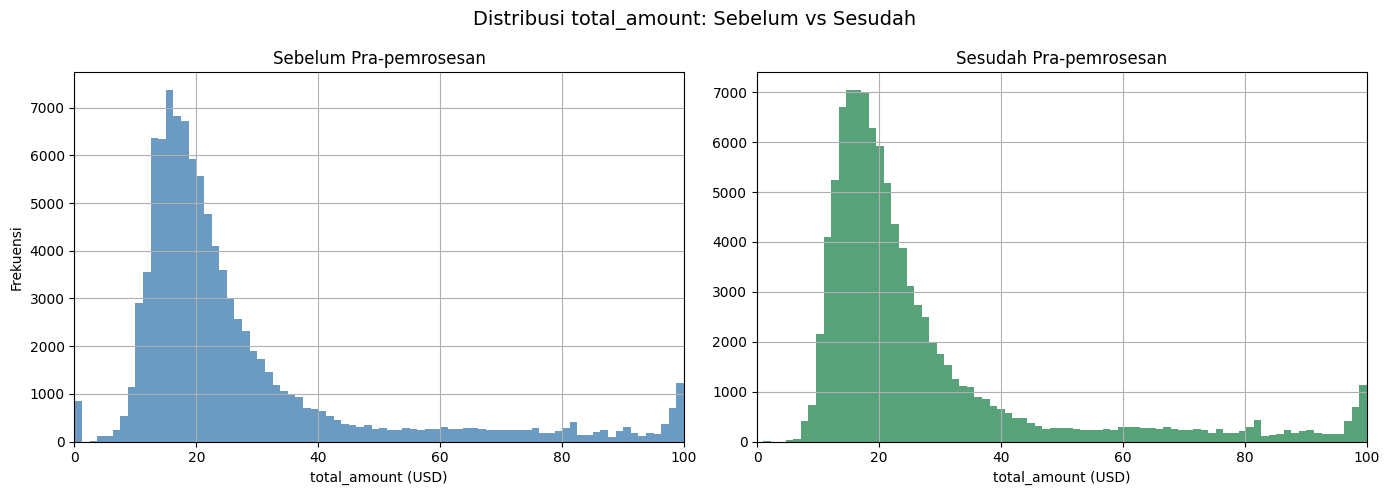

In [32]:
# ============================================================
# GRAFIK: distribusi total_amount sebelum vs sesudah
# ============================================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
batas_x = (0, 100)

# Sampel 100k baris agar cepat
sampel = min(100_000, len(trip))
sampel_bersih = min(100_000, len(bersih))

trip["total_amount"].sample(sampel, random_state=42).clip(*batas_x).hist(
    ax=ax1, bins=80, color="steelblue", edgecolor="none", alpha=0.8
)
ax1.set_title("Sebelum Pra-pemrosesan")
ax1.set_xlabel("total_amount (USD)")
ax1.set_ylabel("Frekuensi")
ax1.set_xlim(batas_x)

bersih["total_amount"].sample(sampel_bersih, random_state=42).clip(*batas_x).hist(
    ax=ax2, bins=80, color="seagreen", edgecolor="none", alpha=0.8
)
ax2.set_title("Sesudah Pra-pemrosesan")
ax2.set_xlabel("total_amount (USD)")
ax2.set_xlim(batas_x)

plt.suptitle("Distribusi total_amount: Sebelum vs Sesudah", fontsize=14)
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/distribusi_total_amount.png", dpi=150, bbox_inches="tight")
plt.show()